# 🚗 Car-Sharing Usage Analysis

### 📍 Politecnico di Torino — ICT for Smart Mobility
### 👩‍💻 Group Project — Individual Contribution

This notebook presents my individual contribution to **Lab 1** of a group project on car-sharing and urban mobility data.

The analysis focuses on **car-sharing usage characterization**, including temporal usage patterns, duration distributions, outlier filtering, and descriptive statistics.

> 🔎 **Scope of this notebook:** Lab 1 — Parts 2, 3, 4, and 5 of my contribution.


## 🎯 Analysis Objectives

- 📈 Characterize booking and parking duration distributions using empirical CDFs.
- ⏱️ Analyze system utilization by hour of day across selected cities.
- 🧹 Define filtering criteria for unusually short or long booking and parking durations.
- 🔄 Compare filtered and unfiltered utilization patterns.
- 📊 Compute daily descriptive statistics after filtering.


## 🔐 Data Access

The original course analysis used a MongoDB database provided by Politecnico di Torino.

**Database credentials and private connection details are intentionally not included in this public repository.**

To run the database-dependent cells with authorized access, configure the MongoDB connection string through the environment variable `MONGO_URI`.

The original course dataset is also **not redistributed in this repository**.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytz
from datetime import datetime, timedelta
from pymongo import MongoClient

# Public portfolio version:
# credentials are read from an environment variable rather than stored in the notebook.
MONGO_URI = os.getenv("MONGO_URI")

if not MONGO_URI:
    print("Data access not configured. Set the MONGO_URI environment variable to run database-dependent cells.")
    client = None
    db = None
else:
    client = MongoClient(MONGO_URI)
    db = client["carsharing"]
    print("MongoDB connection initialized.")


## 1️⃣ 🚗 Car-Sharing Usage Characterization

**Study period:** November 1, 2017 – January 31, 2018

**Cities:** Amsterdam, Portland, and Stuttgart

The analysis considers booking and parking duration together with temporal usage patterns.


City: Stuttgart, Data Count: 252938, Minimum duration: 44 seconds, Maximum duration: 2423056 seconds
City: Portland, Data Count: 177056, Minimum duration: 43 seconds, Maximum duration: 3199136 seconds
City: Amsterdam, Data Count: 139628, Minimum duration: 44 seconds, Maximum duration: 3940676 seconds


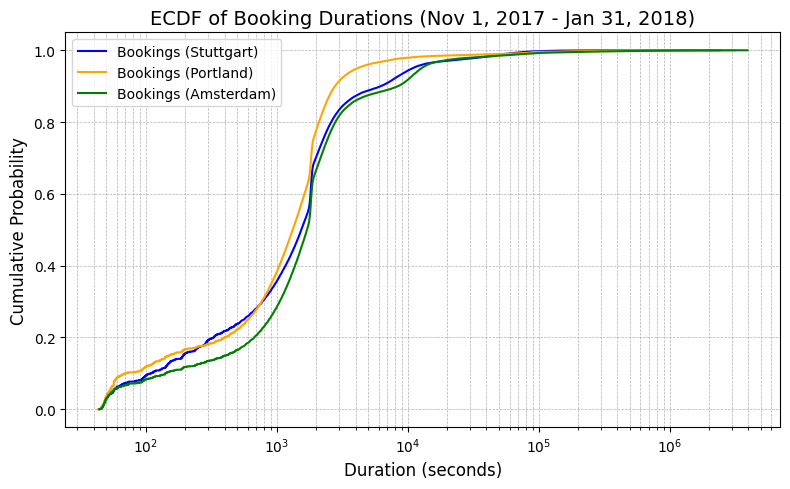

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Function to query booking data from MongoDB
def query_booking_data(collection_name, selected_cities, db):
    """
    Query booking data from MongoDB, including init_time and final_time.

    Args:
        collection_name (str): MongoDB collection name.
        selected_cities (list): List of city names to filter.
        db (object): MongoDB database object.

    Returns:
        pd.DataFrame: DataFrame containing city, init_time, final_time, and duration in seconds.
    """
    collection = db[collection_name]
    pipeline = [
        {"$match": {"city": {"$in": selected_cities}}},  # Filter only selected cities
        {"$project": {
            "city": 1,
            "init_time": 1,  # Keep init_time as UNIX timestamp
            "final_time": 1,  # Keep final_time as UNIX timestamp
            "duration_seconds": {"$subtract": ["$final_time", "$init_time"]}  # Duration in seconds
        }}
    ]
    results = list(collection.aggregate(pipeline))
    return pd.DataFrame(results)

# Query booking data
bookings_df = query_booking_data("PermanentBookings", ['Stuttgart', 'Portland', 'Amsterdam'], db)

# Convert UNIX timestamps to datetime in Python
bookings_df['init_date'] = pd.to_datetime(bookings_df['init_time'], unit='s')
bookings_df['final_date'] = pd.to_datetime(bookings_df['final_time'], unit='s')

# Define the period of interest
start_date = datetime(2017, 11, 1)
end_date = datetime(2018, 1, 31)

# Filter booking durations for selected cities within the specified date range
filtered_durations = [
    bookings_df[
        (bookings_df['city'] == city) &
        (bookings_df['init_date'] >= start_date) &
        (bookings_df['init_date'] <= end_date)
    ]['duration_seconds']
    for city in ['Stuttgart', 'Portland', 'Amsterdam']
]

# Debug: Check filtered data
for city, data in zip(['Stuttgart', 'Portland', 'Amsterdam'], filtered_durations):
    print(f"City: {city}, Data Count: {len(data)}, Minimum duration: {data.min()} seconds, Maximum duration: {data.max()} seconds")

# Function to calculate ECDF
def calculate_ecdf(data):
    """
    Calculate the x (sorted data) and y (cumulative probabilities) for an ECDF plot.

    Args:
        data (pd.Series or np.array): The data to calculate the ECDF for.

    Returns:
        tuple: x (sorted data), y (cumulative probabilities).
    """
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

# Plot ECDF for each city
plt.figure(figsize=(8, 5))
colors = ['blue', 'orange', 'green']
for city, data, color in zip(['Stuttgart', 'Portland', 'Amsterdam'], filtered_durations, colors):
    x, y = calculate_ecdf(data)
    plt.plot(x, y, label=f"Bookings ({city})", color=color)

# Set axis labels, title, and legend
plt.title("ECDF of Booking Durations (Nov 1, 2017 - Jan 31, 2018)", fontsize=14)
plt.xlabel("Duration (seconds)", fontsize=12)
plt.ylabel("Cumulative Probability", fontsize=12)
plt.xscale('log')  # Logarithmic scale for better visualization
plt.legend(fontsize=10)
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()

# Show the ECDF plot
plt.show()


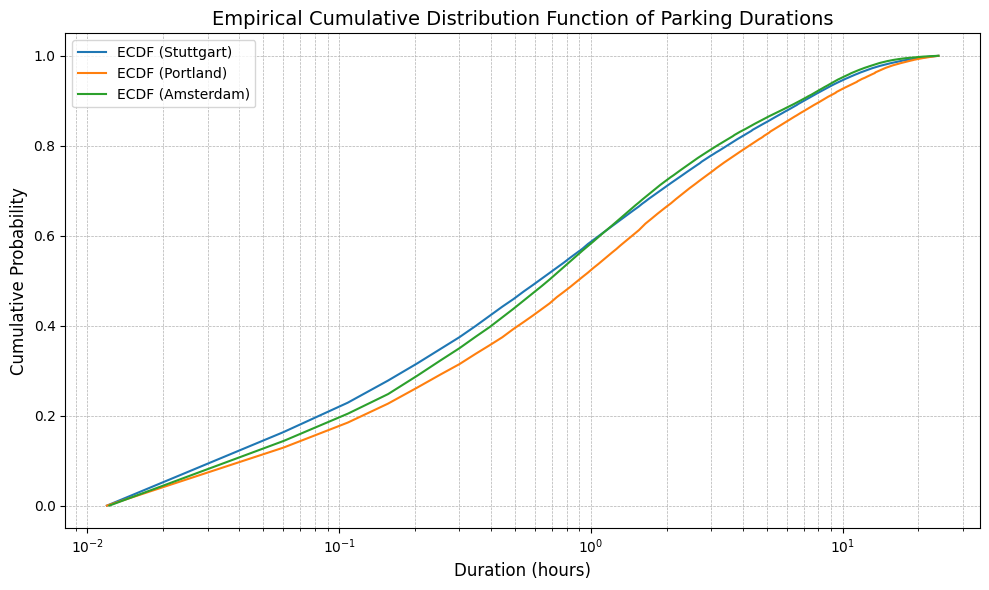

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Define the period of interest as UNIX timestamps
start_date = datetime(2017, 11, 1)
end_date = datetime(2018, 1, 31)
period_begin = int(start_date.timestamp())
period_end = int(end_date.timestamp())

# Query MongoDB for parking data and return data for ECDF calculation
def get_data_for_ecdf(city, collection_name, db, max_duration=86400, dynamic_min=False):
    """
    Fetch data for ECDF from MongoDB.

    Args:
        city (str): City name to filter.
        collection_name (str): Collection to query (e.g., "PermanentParkings").
        db (object): MongoDB database object.
        max_duration (int): Maximum allowed duration in seconds.
        dynamic_min (bool): If True, calculate the real minimum duration dynamically.

    Returns:
        dict: Contains Min, Max, DurationList, and TotalEntries.
    """
    city_filter = {"city": city, "init_time": {"$gte": period_begin, "$lte": period_end}}

    # Fetch minimum duration dynamically if required
    if dynamic_min:
        min_cursor = db[collection_name].aggregate(
            [{"$match": city_filter}, {"$project": {"duration": {"$subtract": ["$final_time", "$init_time"]}}},
             {"$sort": {"duration": 1}}, {"$limit": 1}]
        )
        min_duration = next(min_cursor, {}).get("duration", 0)
    else:
        min_duration = 0

    # Query for all durations in the specified range
    cursor = db[collection_name].aggregate(
        [{"$match": city_filter},
         {"$project": {"duration": {"$subtract": ["$final_time", "$init_time"]}}},
         {"$match": {"duration": {"$lte": max_duration}}},
         {"$sort": {"duration": 1}}],
        allowDiskUse=True
    )
    duration_list = [doc["duration"] for doc in cursor]
    total_entries = len(duration_list)

    return {"Min": min_duration, "Max": max_duration, "DurationList": duration_list, "TotalEntries": total_entries}

# Function to compute ECDF x and y values
def compute_ecdf(data, num_points=500):
    """
    Compute x and y values for ECDF.

    Args:
        data (list): List of durations.
        num_points (int): Number of points on the x-axis.

    Returns:
        tuple: x (sorted data points), y (cumulative probabilities).
    """
    x = np.linspace(min(data), max(data), num_points)
    y = np.searchsorted(np.sort(data), x, side="right") / len(data)
    return x, y

# Query parking data for each city
def query_and_plot_ecdf(cities, collection_name, db, max_duration=86400):
    """
    Query parking data and plot ECDFs for the specified cities.

    Args:
        cities (list): List of city names to analyze.
        collection_name (str): MongoDB collection name.
        db (object): MongoDB database object.
        max_duration (int): Maximum parking duration to consider in seconds.
    """
    plt.figure(figsize=(10, 6))
    for city in cities:
        cdf_data = get_data_for_ecdf(city, collection_name, db, max_duration=max_duration)
        x, y = compute_ecdf(cdf_data["DurationList"])
        plt.plot(x / 3600, y, label=f"ECDF ({city})")  # Convert seconds to hours

    # Plot configuration
    plt.title("Empirical Cumulative Distribution Function of Parking Durations", fontsize=14)
    plt.xlabel("Duration (hours)", fontsize=12)
    plt.ylabel("Cumulative Probability", fontsize=12)
    plt.xscale("log")  # Use log scale for better visualization
    plt.grid(which="both", linestyle="--", linewidth=0.5)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

# Define cities to analyze and collection name
cities = ["Stuttgart", "Portland", "Amsterdam"]
collection_name = "PermanentParkings"

# Call the function to query and plot ECDF
query_and_plot_ecdf(cities, collection_name, db)


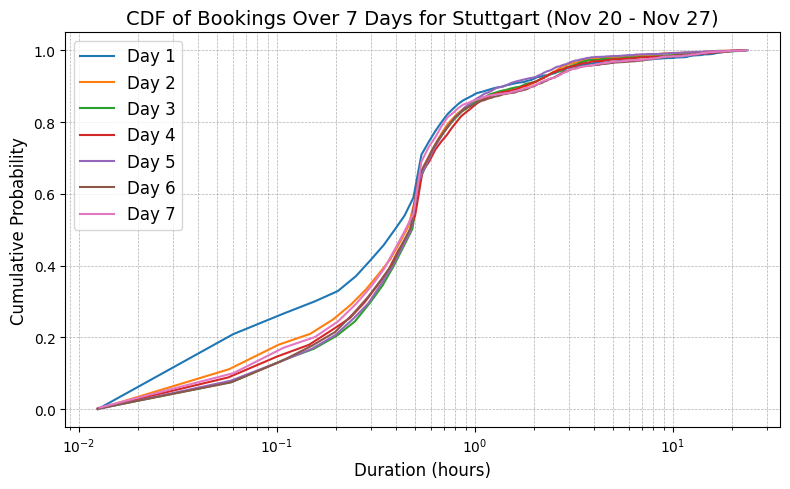

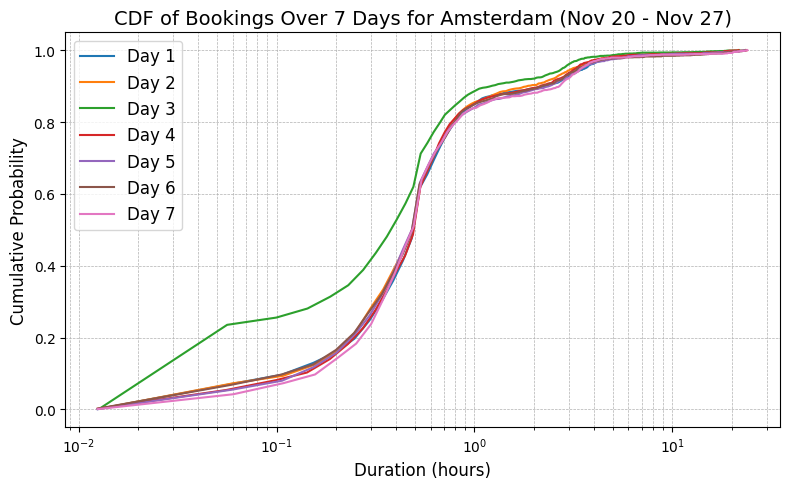

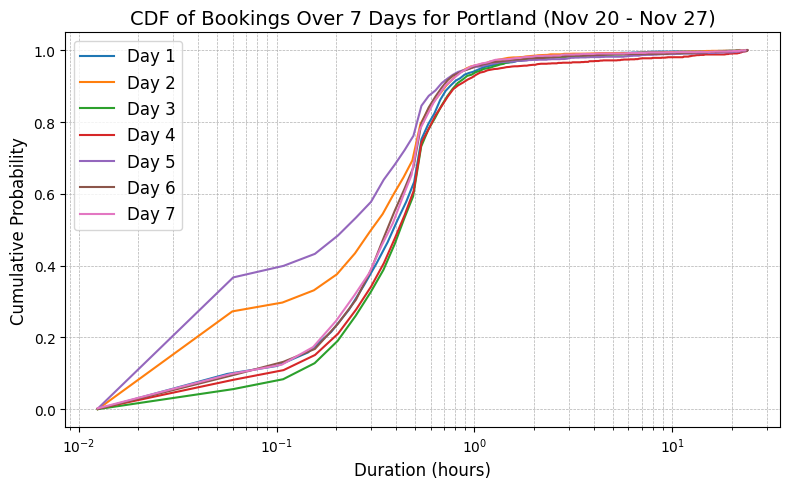

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Define the period of interest as UNIX timestamps
start_date = datetime(2017, 11, 20)
end_date = datetime(2017, 11, 27)
period_begin = int(start_date.timestamp())
period_end = int(end_date.timestamp())

# Break the period into daily intervals
def get_daily_intervals(period_begin, period_end):
    """
    Generate a list of start and end timestamps for daily intervals.

    Args:
        period_begin (int): Start of the period (UNIX timestamp).
        period_end (int): End of the period (UNIX timestamp).

    Returns:
        list: List of tuples (start, end) for each daily interval.
    """
    intervals = []
    current_start = period_begin
    while current_start < period_end:
        current_end = current_start + 86400  # One day in seconds
        intervals.append((current_start, min(current_end, period_end)))
        current_start = current_end
    return intervals

# Query MongoDB for parking data for a specific interval
def get_data_for_ecdf_interval(city, collection_name, db, start, end, max_duration=86400):
    """
    Fetch data for ECDF from MongoDB for a specific time interval.

    Args:
        city (str): City name to filter.
        collection_name (str): Collection to query (e.g., "PermanentBookings").
        db (object): MongoDB database object.
        start (int): Start of the interval (UNIX timestamp).
        end (int): End of the interval (UNIX timestamp).
        max_duration (int): Maximum allowed duration in seconds.

    Returns:
        list: List of durations for the specified interval.
    """
    city_filter = {"city": city, "init_time": {"$gte": start, "$lte": end}}
    cursor = db[collection_name].aggregate(
        [{"$match": city_filter},
         {"$project": {"duration": {"$subtract": ["$final_time", "$init_time"]}}},  # Calculate duration
         {"$match": {"duration": {"$lte": max_duration}}},  # Filter by max duration
         {"$sort": {"duration": 1}}],
        allowDiskUse=True
    )
    return [doc["duration"] for doc in cursor]

# Compute ECDF
def compute_ecdf(data, num_points=500):
    """
    Compute x and y values for ECDF.

    Args:
        data (list): List of durations.
        num_points (int): Number of points on the x-axis.

    Returns:
        tuple: x-axis values, y-axis values.
    """
    if len(data) == 0:
        return [], []
    x = np.linspace(min(data), max(data), num_points)
    y = np.searchsorted(np.sort(data), x, side="right") / len(data)
    return x, y

# Plot ECDF for a single city over 7 days
def plot_ecdf_for_city(city, collection_name, db, interval_days=1, max_duration=86400):
    """
    Plot ECDFs for parking durations over 7 days for a single city.

    Args:
        city (str): City name to analyze.
        collection_name (str): MongoDB collection name.
        db (object): MongoDB database object.
        interval_days (int): Length of each time interval in days.
        max_duration (int): Maximum parking duration to consider in seconds.
    """
    intervals = get_daily_intervals(period_begin, period_end)
    plt.figure(figsize=(8, 5))

    for i, (start, end) in enumerate(intervals):
        durations = get_data_for_ecdf_interval(city, collection_name, db, start, end, max_duration)
        if durations:
            x, y = compute_ecdf(durations, num_points=500)
            plt.plot(x / 3600, y, label=f"Day {i+1}")  # Convert seconds to hours

    # Plot configuration
    plt.title(f"CDF of Bookings Over 7 Days for {city} (Nov 20 - Nov 27)", fontsize=14)
    plt.xlabel("Duration (hours)", fontsize=12)
    plt.ylabel("Cumulative Probability", fontsize=12)
    plt.xscale("log")  # Use log scale for better visualization
    plt.grid(which="both", linestyle="--", linewidth=0.5)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

# Define parameters
collection_name = "PermanentBookings"

# Plot for Stuttgart
plot_ecdf_for_city("Stuttgart", collection_name, db, interval_days=1, max_duration=86400)

# Plot for Amsterdam
plot_ecdf_for_city("Amsterdam", collection_name, db, interval_days=1, max_duration=86400)

# Plot for Portland
plot_ecdf_for_city("Portland", collection_name, db, interval_days=1, max_duration=86400)


### ⏱️ Temporal Usage Patterns

System utilization was aggregated by hour of day and compared across the three cities, using the local time zone of each city.


Connection successful!


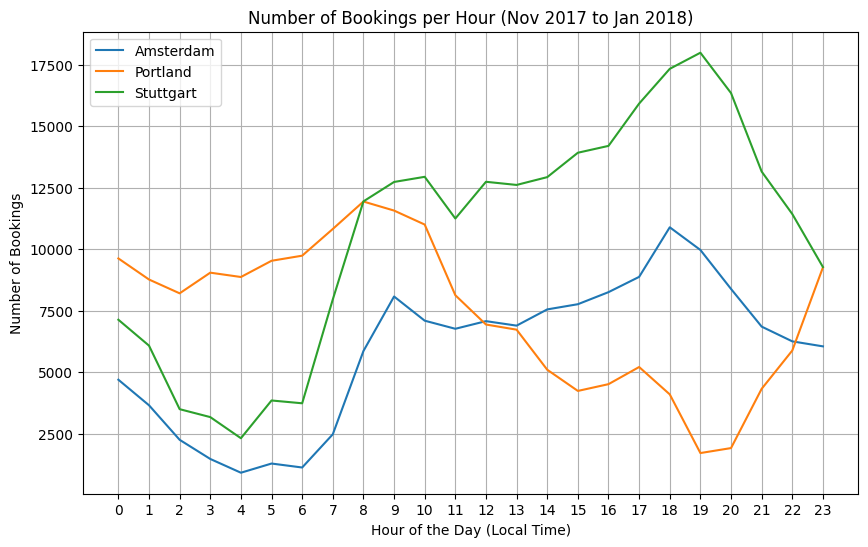

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import pytz  # Library for timezone

# Define time zones for cities
timezones = {
    "Amsterdam": pytz.timezone("Europe/Amsterdam"),
    "Portland": pytz.timezone("America/Los_Angeles"),
    "Stuttgart": pytz.timezone("Europe/Berlin")
}


if db is None:
    raise RuntimeError("Set MONGO_URI before running this database-dependent analysis cell.")
collection = db["PermanentBookings"]
start_date = pd.to_datetime("2017-11-01T00:00:00Z")
end_date = pd.to_datetime("2018-01-31T23:59:59Z")

cities = ["Amsterdam", "Portland", "Stuttgart"]
city_data = {}

for city in cities:
    # Query to data
    results = list(collection.find(
        {
            "city": city,
            "init_date": {
                "$gte": start_date,
                "$lte": end_date
            }
        },
        { "init_date": 1 }
    ))

    if not results:
        print(f"No data found for city: {city}")
        continue

    # Convert results into a DataFrame
    df = pd.DataFrame(results)
    df['UTC_Date'] = pd.to_datetime(df['init_date'])
    local_tz = timezones[city]
    df['Local_Date'] = df['UTC_Date'].dt.tz_localize('UTC').dt.tz_convert(local_tz)
    df['Local_Hour'] = df['Local_Date'].dt.hour

   # print(f"Data for {city} after timezone conversion:")
   # print(df.head())
    hourly_data = df.groupby('Local_Hour').size().reset_index(name='Count')
    #print(f"Grouped data for {city}:")
    #print(hourly_data.head())

    city_data[city] = hourly_data

plt.figure(figsize=(10, 6))
for city, data in city_data.items():
    if data.empty:
        print(f"No data to plot for city: {city}")
    else:
        plt.plot(data['Local_Hour'], data['Count'],  label=city)

plt.title("Number of Bookings per Hour (Nov 2017 to Jan 2018)")
plt.xlabel("Hour of the Day (Local Time)")
plt.ylabel("Number of Bookings")
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.show()


Connection successful!


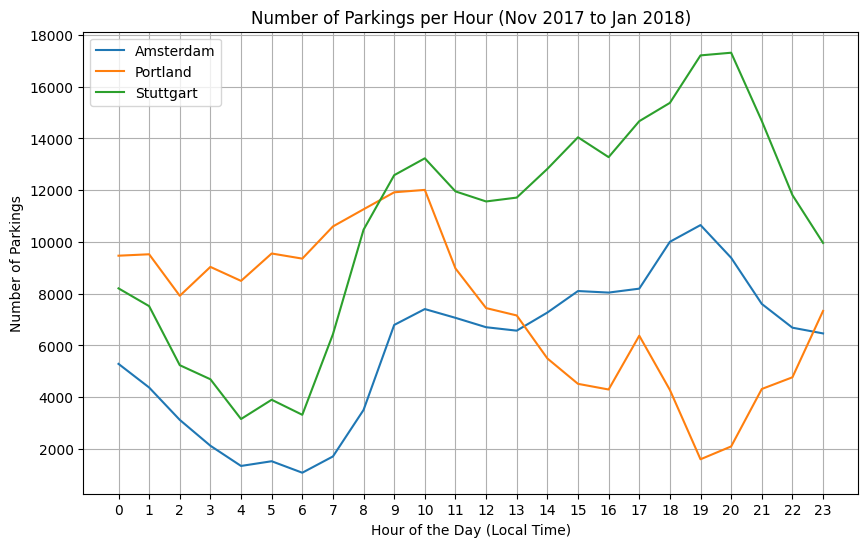

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import pytz  # Library for timezone

# Define time zones for cities
timezones = {
    "Amsterdam": pytz.timezone("Europe/Amsterdam"),
    "Portland": pytz.timezone("America/Los_Angeles"),
    "Stuttgart": pytz.timezone("Europe/Berlin")
}


if db is None:
    raise RuntimeError("Set MONGO_URI before running this database-dependent analysis cell.")
collection = db["PermanentParkings"]
start_date = pd.to_datetime("2017-11-01T00:00:00Z")
end_date = pd.to_datetime("2018-01-31T23:59:59Z")

cities = ["Amsterdam", "Portland", "Stuttgart"]
city_data = {}

for city in cities:
    # Query to data
    results = list(collection.find(
        {
            "city": city,
            "init_date": {
                "$gte": start_date,
                "$lte": end_date
            }
        },
        { "init_date": 1 }
    ))

    if not results:
        print(f"No data found for city: {city}")
        continue

    # Convert results into a DataFrame
    df = pd.DataFrame(results)
    df['UTC_Date'] = pd.to_datetime(df['init_date'])
    local_tz = timezones[city]
    df['Local_Date'] = df['UTC_Date'].dt.tz_localize('UTC').dt.tz_convert(local_tz)
    df['Local_Hour'] = df['Local_Date'].dt.hour

   # print(f"Data for {city} after timezone conversion:")
   # print(df.head())

    hourly_data = df.groupby('Local_Hour').size().reset_index(name='Count')
   # print(f"Grouped data for {city}:")
   # print(hourly_data.head())
    city_data[city] = hourly_data

plt.figure(figsize=(10, 6))
for city, data in city_data.items():
    if data.empty:
        print(f"No data to plot for city: {city}")
    else:
        plt.plot(data['Local_Hour'], data['Count'],  label=city)

plt.title("Number of Parkings per Hour (Nov 2017 to Jan 2018)")
plt.xlabel("Hour of the Day (Local Time)")
plt.ylabel("Number of Parkings")
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.show()


## 2️⃣ 🧹 Outlier Filtering Criteria

The analysis used the following duration-based filtering criteria:

| Event | Minimum duration | Maximum duration |
|---|---:|---:|
| 🚗 Booking | 2 minutes | 180 minutes |
| 🅿️ Parking | 1 minute | 180 minutes |

These thresholds were used to remove unusually short or long events before the filtered utilization and statistical analyses.


## 3️⃣ 🔄 Filtered vs. Unfiltered Utilization

After applying the duration filters, hourly booking and parking utilization were recalculated and compared with the unfiltered patterns.

The filtered event distributions were also examined through CDF-based analysis.


Connection successful!


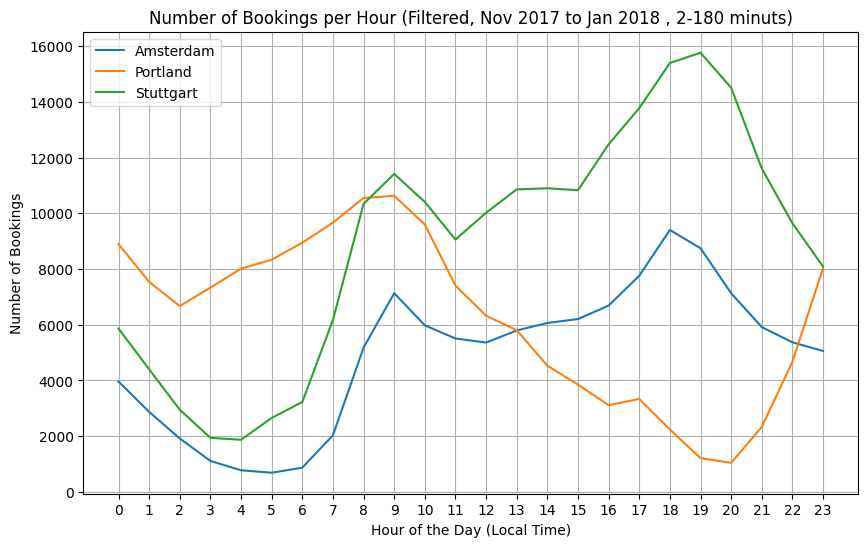

In [26]:


import pandas as pd
import matplotlib.pyplot as plt
import pytz  # Library for timezone

# Define time zones for cities
timezones = {
    "Amsterdam": pytz.timezone("Europe/Amsterdam"),
    "Portland": pytz.timezone("America/Los_Angeles"),
    "Stuttgart": pytz.timezone("Europe/Berlin")
}


if db is None:
    raise RuntimeError("Set MONGO_URI before running this database-dependent analysis cell.")
collection = db["PermanentBookings"]
# Define the date
start_date = pd.to_datetime("2017-11-01T00:00:00Z")
end_date = pd.to_datetime("2018-01-31T23:59:59Z")

cities = ["Amsterdam", "Portland", "Stuttgart"]
city_data = {}

for city in cities:
    # Query to data
    results = list(collection.find(
        {
            "city": city,
            "init_date": {
                "$gte": start_date,
                "$lte": end_date
            }
        },
        { "init_date": 1, "final_date": 1 }
    ))

    if not results:
        print(f"No data found for city: {city}")
        continue

    # Convert results into a DataFrame
    df = pd.DataFrame(results)
    df['UTC_Init'] = pd.to_datetime(df['init_date'])
    df['UTC_Final'] = pd.to_datetime(df['final_date'])

    # Calculate duration in minutes
    df['Duration'] = (df['UTC_Final'] - df['UTC_Init']).dt.total_seconds() / 60

    # Filter data based on duration
    filtered_df = df[(df['Duration'] >= 2) & (df['Duration'] <= 180)].copy()

    # Convert to local time
    local_tz = timezones[city]
    filtered_df.loc[:, 'Local_Init'] = filtered_df['UTC_Init'].dt.tz_localize('UTC').dt.tz_convert(local_tz)
    filtered_df.loc[:, 'Local_Hour'] = filtered_df['Local_Init'].dt.hour

    #print(f"Data for {city} after timezone conversion and filtering:")
    #print(filtered_df.head())

    # Group by Local Hour and count
    hourly_data = filtered_df.groupby('Local_Hour').size().reset_index(name='Count')
   # print(f"Grouped data for {city}:")
   # print(hourly_data.head())
    city_data[city] = hourly_data

# Plot
plt.figure(figsize=(10, 6))
for city, data in city_data.items():
    if data.empty:
        print(f"No data to plot for city: {city}")
    else:
        plt.plot(data['Local_Hour'], data['Count'],  label=city)

# Configure the plot
plt.title("Number of Bookings per Hour (Filtered, Nov 2017 to Jan 2018 , 2-180 minuts)")
plt.xlabel("Hour of the Day (Local Time)")
plt.ylabel("Number of Bookings")
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.show()


Connection successful!


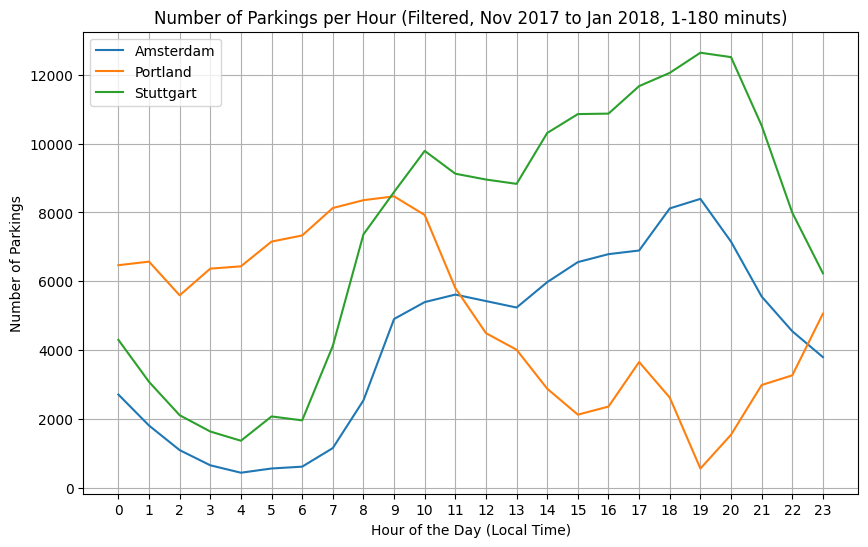

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import pytz  # Library for timezone

# Define time zones for cities
timezones = {
    "Amsterdam": pytz.timezone("Europe/Amsterdam"),
    "Portland": pytz.timezone("America/Los_Angeles"),
    "Stuttgart": pytz.timezone("Europe/Berlin")
}


if db is None:
    raise RuntimeError("Set MONGO_URI before running this database-dependent analysis cell.")
collection = db["PermanentParkings"]
# Define the date
start_date = pd.to_datetime("2017-11-01T00:00:00Z")
end_date = pd.to_datetime("2018-01-31T23:59:59Z")

cities = ["Amsterdam", "Portland", "Stuttgart"]
city_data = {}

for city in cities:
    # Query to data
    results = list(collection.find(
        {
            "city": city,
            "init_date": {
                "$gte": start_date,
                "$lte": end_date
            }
        },
        { "init_date": 1, "final_date": 1 }
    ))

    if not results:
        print(f"No data found for city: {city}")
        continue

    # Convert results into a DataFrame
    df = pd.DataFrame(results)
    df['UTC_Init'] = pd.to_datetime(df['init_date'])
    df['UTC_Final'] = pd.to_datetime(df['final_date'])

    # Calculate parking duration in minutes
    df['Parking_Duration'] = (df['UTC_Final'] - df['UTC_Init']).dt.total_seconds() / 60

    # Filter data based on parking duration
    filtered_df = df[(df['Parking_Duration'] >= 1) & (df['Parking_Duration'] <= 180)].copy()

    # Convert to local time
    local_tz = timezones[city]
    filtered_df.loc[:, 'Local_Init'] = filtered_df['UTC_Init'].dt.tz_localize('UTC').dt.tz_convert(local_tz)
    filtered_df.loc[:, 'Local_Hour'] = filtered_df['Local_Init'].dt.hour

    # Group by Local Hour and count
    hourly_data = filtered_df.groupby('Local_Hour').size().reset_index(name='Count')
    city_data[city] = hourly_data

# Plot
plt.figure(figsize=(10, 6))
for city, data in city_data.items():
    if data.empty:
        print(f"No data to plot for city: {city}")
    else:
        plt.plot(data['Local_Hour'], data['Count'], label=city)

# plot
plt.title("Number of Parkings per Hour (Filtered, Nov 2017 to Jan 2018, 1-180 minuts)")
plt.xlabel("Hour of the Day (Local Time)")
plt.ylabel("Number of Parkings")
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.show()


## 4️⃣ 📊 Daily Descriptive Statistics

After filtering, booking and parking durations were summarized over time using:

- Mean
- Median
- Standard deviation
- Percentiles

The original analysis included daily duration statistics for selected cities.


Connection successful!


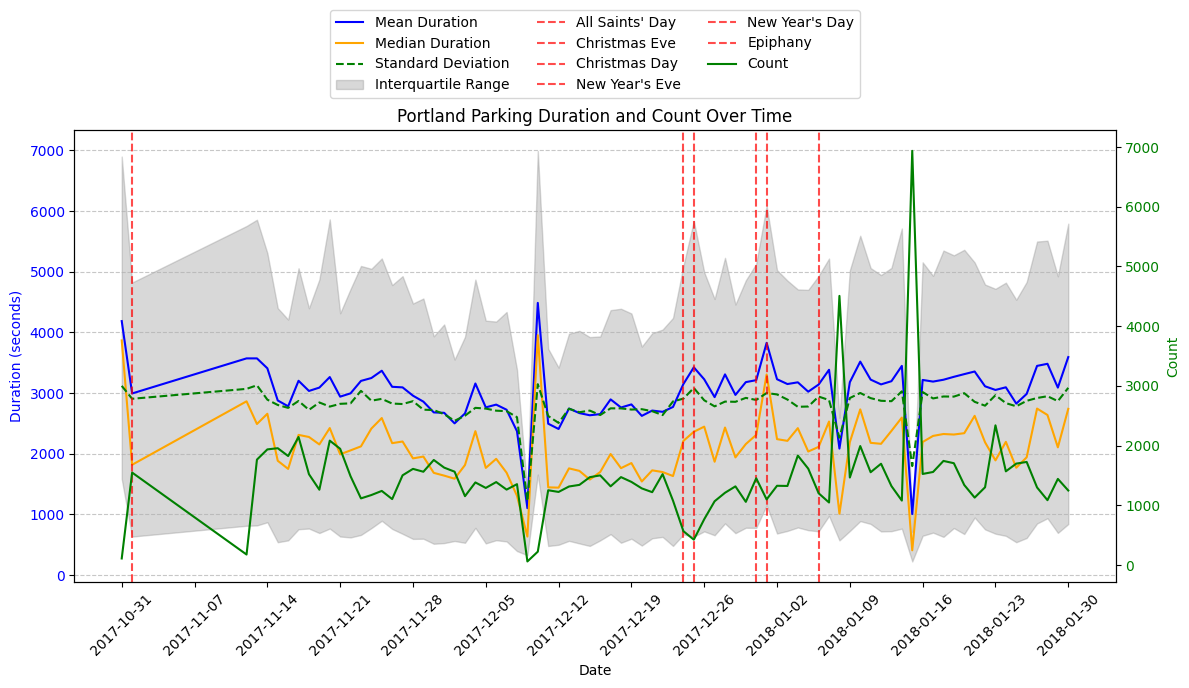

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import pytz  # Library for timezone
import numpy as np

# Define time zone for Portland
timezone = pytz.timezone("America/Los_Angeles")


if db is None:
    raise RuntimeError("Set MONGO_URI before running this database-dependent analysis cell.")
collection = db["PermanentParkings"]
# Define the date
start_date = pd.to_datetime("2017-11-01T00:00:00Z")
end_date = pd.to_datetime("2018-01-31T23:59:59Z")

# Fetch data for Portland
results = list(collection.find(
    {
        "city": "Portland",
        "init_date": {
            "$gte": start_date,
            "$lte": end_date
        }
    },
    {"init_date": 1, "final_date": 1}
))

if not results:
    print("No data found for Portland.")
else:
    # Convert results into a DataFrame
    df = pd.DataFrame(results)
    df['UTC_Init'] = pd.to_datetime(df['init_date'])
    df['UTC_Final'] = pd.to_datetime(df['final_date'])

    # Calculate parking duration in seconds
    df['Duration'] = (df['UTC_Final'] - df['UTC_Init']).dt.total_seconds()

    # Convert to local time
    df['Local_Init'] = df['UTC_Init'].dt.tz_localize('UTC').dt.tz_convert(timezone)
    df['Local_Date'] = df['Local_Init'].dt.date

    # Filter data based on duration (between 1 minute and 3 hours)
    filtered_df = df[(df['Duration'] >= 60) & (df['Duration'] <= 10800)]  # 1 minute to 3 hours

    # calculate statistics
    daily_stats = filtered_df.groupby('Local_Date')['Duration'].agg([
        ('Mean', 'mean'),  # Use Pandas
        ('Median', 'median'),  # Use Pandas
        ('Std', lambda x: np.std(x, ddof=1) if len(x) > 1 else 0),  #  Std
        ('25th Percentile', lambda x: np.percentile(x, 25)),
        ('75th Percentile', lambda x: np.percentile(x, 75))
    ]).reset_index()

    #  daily counts
    daily_counts = filtered_df.groupby('Local_Date').size().reset_index(name='Count')

    # Merge stats and counts
    daily_stats = pd.merge(daily_stats, daily_counts, left_on='Local_Date', right_on='Local_Date', how='left')

    # Define holidays
    holidays = {
        "All Saints' Day": "2017-11-01",
        "Christmas Eve": "2017-12-24",
        "Christmas Day": "2017-12-25",
        "New Year's Eve": "2017-12-31",
        "New Year's Day": "2018-01-01",
        "Epiphany": "2018-01-06"
    }

    # Plot statistics
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot mean, median, and standard deviation
    ax1.plot(daily_stats['Local_Date'], daily_stats['Mean'], label='Mean Duration', color='blue')
    ax1.plot(daily_stats['Local_Date'], daily_stats['Median'], label='Median Duration', color='orange')
    ax1.plot(daily_stats['Local_Date'], daily_stats['Std'], label='Standard Deviation', color='green', linestyle='--')

    # Plot percentiles
    ax1.fill_between(
        daily_stats['Local_Date'],
        daily_stats['25th Percentile'],
        daily_stats['75th Percentile'],
        color='gray', alpha=0.3, label='Interquartile Range'
    )

    ax1.set_xlabel('Date')
    ax1.set_ylabel('Duration (seconds)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Plot count on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(daily_stats['Local_Date'], daily_stats['Count'], label='Count', color='green')
    ax2.set_ylabel('Count', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Highlight holidays
    for holiday, date in holidays.items():
        ax1.axvline(pd.to_datetime(date), color='red', linestyle='--', alpha=0.7, label=holiday)

    # Set x-axis ticks to weekly intervals
    ax1.set_xticks(pd.date_range(start=daily_stats['Local_Date'].min(), end=daily_stats['Local_Date'].max(), freq='7D'))
    ax1.set_xticklabels(pd.date_range(start=daily_stats['Local_Date'].min(), end=daily_stats['Local_Date'].max(), freq='7D').strftime('%Y-%m-%d'), rotation=45)

    # Add legend
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)
    plt.title('Portland Parking Duration and Count Over Time')
    plt.tight_layout()
    plt.show()


Connection successful!


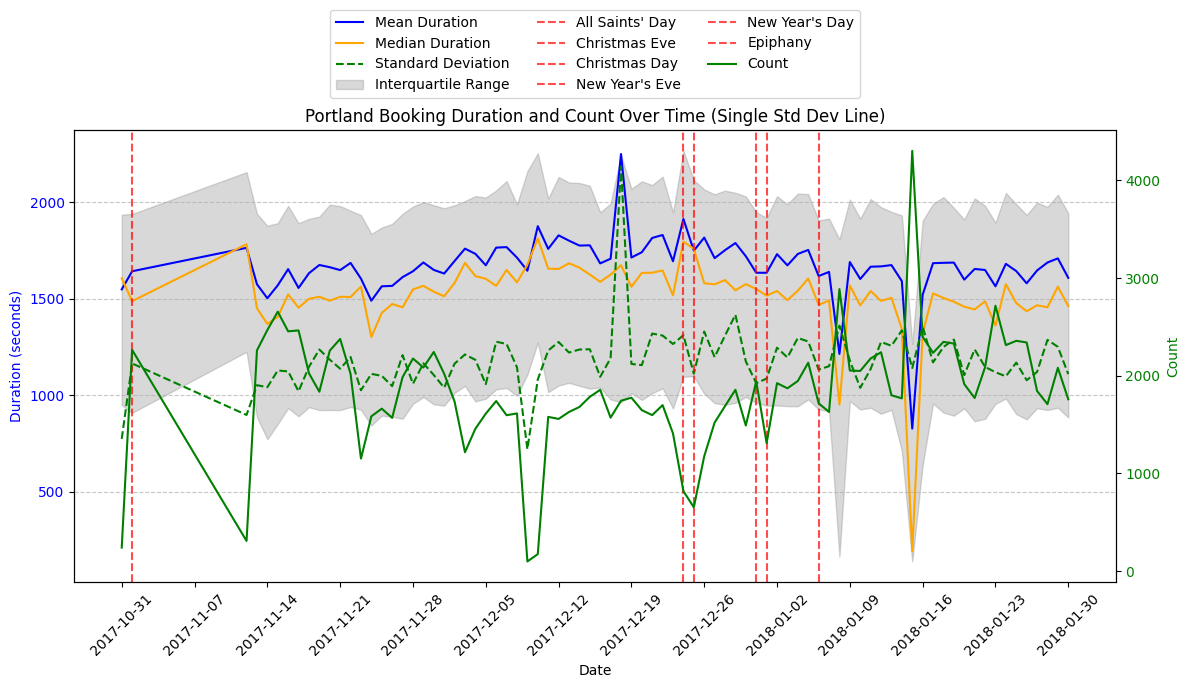

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import pytz  # Library for timezone
import numpy as np

# Define time zone for Portland
timezone = pytz.timezone("America/Los_Angeles")


if db is None:
    raise RuntimeError("Set MONGO_URI before running this database-dependent analysis cell.")
collection = db["PermanentBookings"]
# Define the date
start_date = pd.to_datetime("2017-11-01T00:00:00Z")
end_date = pd.to_datetime("2018-01-31T23:59:59Z")

# Fetch data for Portland
results = list(collection.find(
    {
        "city": "Portland",
        "init_date": {
            "$gte": start_date,
            "$lte": end_date
        }
    },
    {"init_date": 1, "final_date": 1}
))

if not results:
    print("No data found for Portland.")
else:
    # Convert results into a DataFrame
    df = pd.DataFrame(results)
    df['UTC_Init'] = pd.to_datetime(df['init_date'])
    df['UTC_Final'] = pd.to_datetime(df['final_date'])

    # Calculate booking duration in seconds
    df['Duration'] = (df['UTC_Final'] - df['UTC_Init']).dt.total_seconds()

    # Convert to local time
    df['Local_Init'] = df['UTC_Init'].dt.tz_localize('UTC').dt.tz_convert(timezone)
    df['Local_Date'] = df['Local_Init'].dt.date

    # Filter data based on duration (e.g., between 2 minutes and 3 hours)
    filtered_df = df[(df['Duration'] >= 120) & (df['Duration'] <= 10800)]

    #  calculate statistics
    daily_stats = filtered_df.groupby('Local_Date')['Duration'].agg([
        ('Mean', 'mean'),  # Use Pandas
        ('Median', 'median'),  # Use Pandas
        ('Std', lambda x: np.std(x, ddof=1) if len(x) > 1 else 0),  #  Std
        ('25th Percentile', lambda x: np.percentile(x, 25)),
        ('75th Percentile', lambda x: np.percentile(x, 75))
    ]).reset_index()

    #  daily counts
    daily_counts = filtered_df.groupby('Local_Date').size().reset_index(name='Count')

    # Merge stats and counts
    daily_stats = pd.merge(daily_stats, daily_counts, left_on='Local_Date', right_on='Local_Date', how='left')

    # Define holidays
    holidays = {
        "All Saints' Day": "2017-11-01",
        "Christmas Eve": "2017-12-24",
        "Christmas Day": "2017-12-25",
        "New Year's Eve": "2017-12-31",
        "New Year's Day": "2018-01-01",
        "Epiphany": "2018-01-06"
    }

    # Plot statistics
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot mean, median, and standard deviation
    ax1.plot(daily_stats['Local_Date'], daily_stats['Mean'], label='Mean Duration', color='blue')
    ax1.plot(daily_stats['Local_Date'], daily_stats['Median'], label='Median Duration', color='orange')
    ax1.plot(daily_stats['Local_Date'], daily_stats['Std'], label='Standard Deviation', color='green', linestyle='--')

    # Plot percentiles
    ax1.fill_between(
        daily_stats['Local_Date'],
        daily_stats['25th Percentile'],
        daily_stats['75th Percentile'],
        color='gray', alpha=0.3, label='Interquartile Range'
    )

    ax1.set_xlabel('Date')
    ax1.set_ylabel('Duration (seconds)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Plot count on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(daily_stats['Local_Date'], daily_stats['Count'], label='Count', color='green')
    ax2.set_ylabel('Count', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Highlight holidays
    for holiday, date in holidays.items():
        ax1.axvline(pd.to_datetime(date), color='red', linestyle='--', alpha=0.7, label=holiday)

    # Set x-axis ticks to weekly intervals
    ax1.set_xticks(pd.date_range(start=daily_stats['Local_Date'].min(), end=daily_stats['Local_Date'].max(), freq='7D'))
    ax1.set_xticklabels(pd.date_range(start=daily_stats['Local_Date'].min(), end=daily_stats['Local_Date'].max(), freq='7D').strftime('%Y-%m-%d'), rotation=45)

    # Add legend
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)
    plt.title('Portland Booking Duration and Count Over Time (Single Std Dev Line)')
    plt.tight_layout()
    plt.show()


Connection successful!


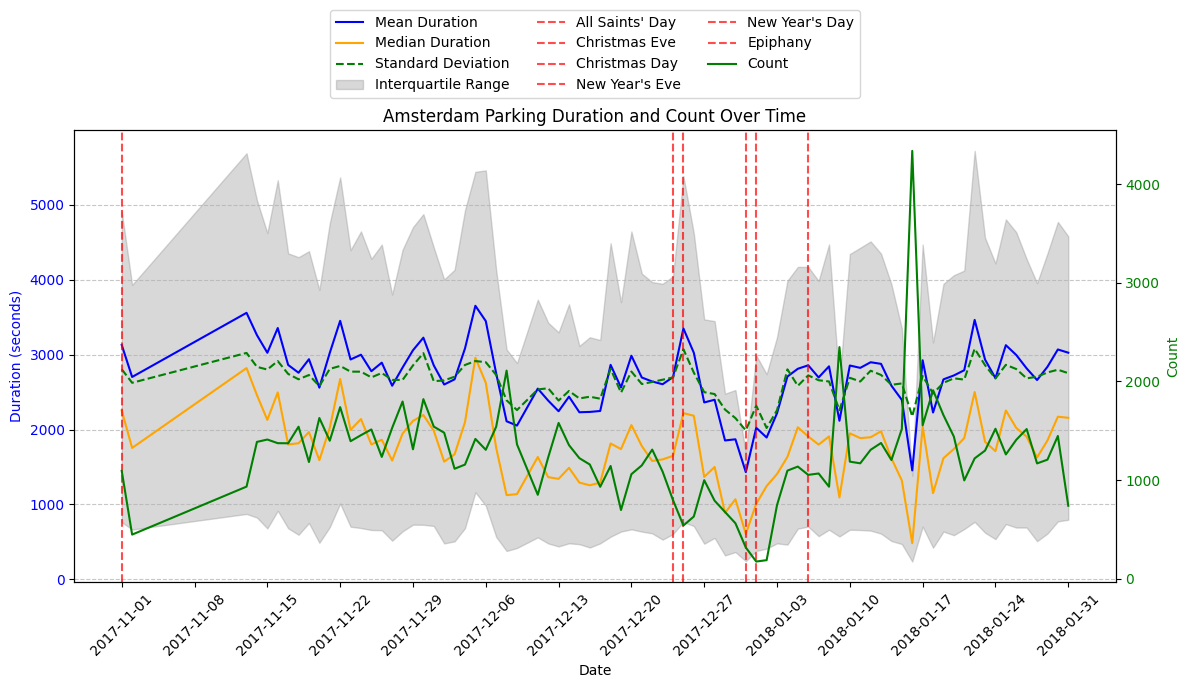

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import pytz  # Library for timezone
import numpy as np

# Define time zone for Portland
timezone = pytz.timezone("Europe/Amsterdam")


if db is None:
    raise RuntimeError("Set MONGO_URI before running this database-dependent analysis cell.")
collection = db["PermanentParkings"]
# Define the date
start_date = pd.to_datetime("2017-11-01T00:00:00Z")
end_date = pd.to_datetime("2018-01-31T23:59:59Z")

# Fetch data for Amsterdam
results = list(collection.find(
    {
        "city": "Amsterdam",
        "init_date": {
            "$gte": start_date,
            "$lte": end_date
        }
    },
    {"init_date": 1, "final_date": 1}
))

if not results:
    print("No data found for Amsterdam.")
else:
    # Convert results into a DataFrame
    df = pd.DataFrame(results)
    df['UTC_Init'] = pd.to_datetime(df['init_date'])
    df['UTC_Final'] = pd.to_datetime(df['final_date'])

    # Calculate parking duration in seconds
    df['Duration'] = (df['UTC_Final'] - df['UTC_Init']).dt.total_seconds()

    # Convert to local time
    df['Local_Init'] = df['UTC_Init'].dt.tz_localize('UTC').dt.tz_convert(timezone)
    df['Local_Date'] = df['Local_Init'].dt.date

    # Filter data based on duration (between 1 minute and 3 hours)
    filtered_df = df[(df['Duration'] >= 60) & (df['Duration'] <= 10800)]  # 1 minute to 3 hours

    # calculate statistics
    daily_stats = filtered_df.groupby('Local_Date')['Duration'].agg([
        ('Mean', 'mean'),  # Use Pandas
        ('Median', 'median'),  # Use Pandas
        ('Std', lambda x: np.std(x, ddof=1) if len(x) > 1 else 0),  #  Std
        ('25th Percentile', lambda x: np.percentile(x, 25)),
        ('75th Percentile', lambda x: np.percentile(x, 75))
    ]).reset_index()

    #  daily counts
    daily_counts = filtered_df.groupby('Local_Date').size().reset_index(name='Count')

    # Merge stats and counts
    daily_stats = pd.merge(daily_stats, daily_counts, left_on='Local_Date', right_on='Local_Date', how='left')

    # Define holidays
    holidays = {
        "All Saints' Day": "2017-11-01",
        "Christmas Eve": "2017-12-24",
        "Christmas Day": "2017-12-25",
        "New Year's Eve": "2017-12-31",
        "New Year's Day": "2018-01-01",
        "Epiphany": "2018-01-06"
    }

    # Plot statistics
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot mean, median, and standard deviation
    ax1.plot(daily_stats['Local_Date'], daily_stats['Mean'], label='Mean Duration', color='blue')
    ax1.plot(daily_stats['Local_Date'], daily_stats['Median'], label='Median Duration', color='orange')
    ax1.plot(daily_stats['Local_Date'], daily_stats['Std'], label='Standard Deviation', color='green', linestyle='--')

    # Plot percentiles
    ax1.fill_between(
        daily_stats['Local_Date'],
        daily_stats['25th Percentile'],
        daily_stats['75th Percentile'],
        color='gray', alpha=0.3, label='Interquartile Range'
    )

    ax1.set_xlabel('Date')
    ax1.set_ylabel('Duration (seconds)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Plot count on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(daily_stats['Local_Date'], daily_stats['Count'], label='Count', color='green')
    ax2.set_ylabel('Count', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Highlight holidays
    for holiday, date in holidays.items():
        ax1.axvline(pd.to_datetime(date), color='red', linestyle='--', alpha=0.7, label=holiday)

    # Set x-axis ticks to weekly intervals
    ax1.set_xticks(pd.date_range(start=daily_stats['Local_Date'].min(), end=daily_stats['Local_Date'].max(), freq='7D'))
    ax1.set_xticklabels(pd.date_range(start=daily_stats['Local_Date'].min(), end=daily_stats['Local_Date'].max(), freq='7D').strftime('%Y-%m-%d'), rotation=45)

    # Add legend
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)
    plt.title('Amsterdam Parking Duration and Count Over Time')
    plt.tight_layout()
    plt.show()


Connection successful!


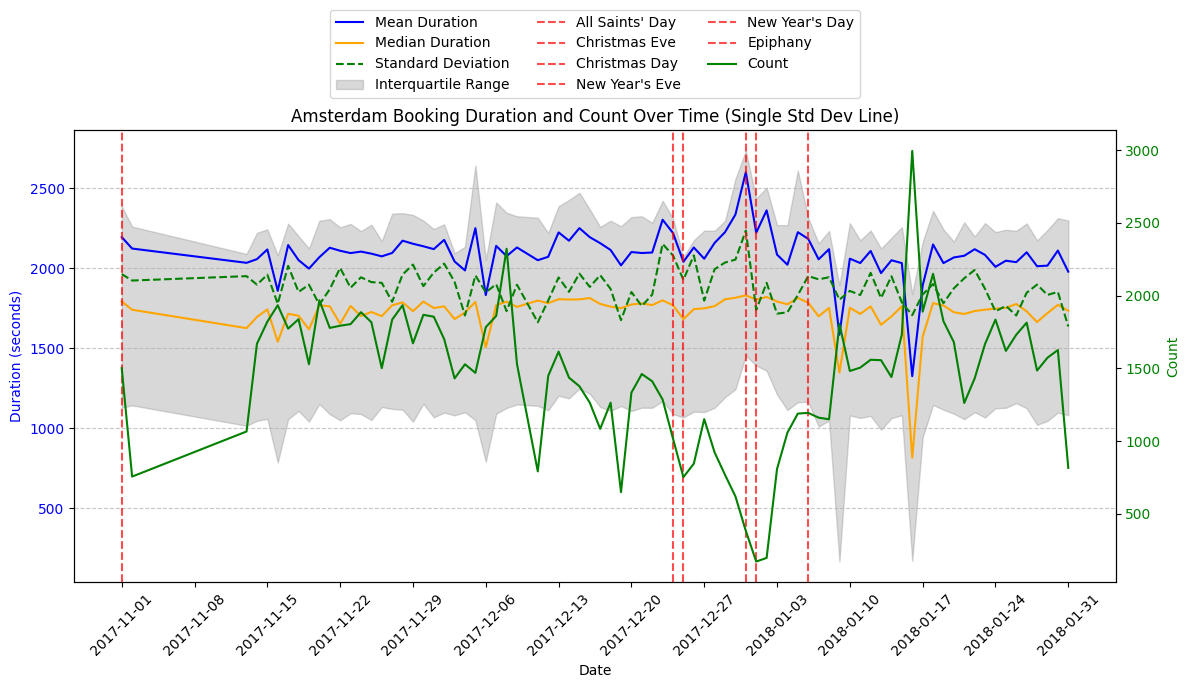

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import pytz  # Library for timezone
import numpy as np

# Define time zone for Portland
timezone = pytz.timezone("Europe/Amsterdam")


if db is None:
    raise RuntimeError("Set MONGO_URI before running this database-dependent analysis cell.")
collection = db["PermanentBookings"]
# Define the date
start_date = pd.to_datetime("2017-11-01T00:00:00Z")
end_date = pd.to_datetime("2018-01-31T23:59:59Z")

# Fetch data for Amsterdam
results = list(collection.find(
    {
        "city": "Amsterdam",
        "init_date": {
            "$gte": start_date,
            "$lte": end_date
        }
    },
    {"init_date": 1, "final_date": 1}
))

if not results:
    print("No data found for Amsterdam.")
else:
    # Convert results into a DataFrame
    df = pd.DataFrame(results)
    df['UTC_Init'] = pd.to_datetime(df['init_date'])
    df['UTC_Final'] = pd.to_datetime(df['final_date'])

    # Calculate booking duration in seconds
    df['Duration'] = (df['UTC_Final'] - df['UTC_Init']).dt.total_seconds()

    # Convert to local time
    df['Local_Init'] = df['UTC_Init'].dt.tz_localize('UTC').dt.tz_convert(timezone)
    df['Local_Date'] = df['Local_Init'].dt.date

    # Filter data based on duration (e.g., between 2 minutes and 3 hours)
    filtered_df = df[(df['Duration'] >= 120) & (df['Duration'] <= 10800)]

    #  calculate statistics
    daily_stats = filtered_df.groupby('Local_Date')['Duration'].agg([
        ('Mean', 'mean'),  # Use Pandas
        ('Median', 'median'),  # Use Pandas
        ('Std', lambda x: np.std(x, ddof=1) if len(x) > 1 else 0),  #  Std
        ('25th Percentile', lambda x: np.percentile(x, 25)),
        ('75th Percentile', lambda x: np.percentile(x, 75))
    ]).reset_index()

    #  daily counts
    daily_counts = filtered_df.groupby('Local_Date').size().reset_index(name='Count')

    # Merge stats and counts
    daily_stats = pd.merge(daily_stats, daily_counts, left_on='Local_Date', right_on='Local_Date', how='left')

    # Define holidays
    holidays = {
        "All Saints' Day": "2017-11-01",
        "Christmas Eve": "2017-12-24",
        "Christmas Day": "2017-12-25",
        "New Year's Eve": "2017-12-31",
        "New Year's Day": "2018-01-01",
        "Epiphany": "2018-01-06"
    }

    # Plot statistics
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot mean, median, and standard deviation
    ax1.plot(daily_stats['Local_Date'], daily_stats['Mean'], label='Mean Duration', color='blue')
    ax1.plot(daily_stats['Local_Date'], daily_stats['Median'], label='Median Duration', color='orange')
    ax1.plot(daily_stats['Local_Date'], daily_stats['Std'], label='Standard Deviation', color='green', linestyle='--')

    # Plot percentiles
    ax1.fill_between(
        daily_stats['Local_Date'],
        daily_stats['25th Percentile'],
        daily_stats['75th Percentile'],
        color='gray', alpha=0.3, label='Interquartile Range'
    )

    ax1.set_xlabel('Date')
    ax1.set_ylabel('Duration (seconds)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Plot count on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(daily_stats['Local_Date'], daily_stats['Count'], label='Count', color='green')
    ax2.set_ylabel('Count', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Highlight holidays
    for holiday, date in holidays.items():
        ax1.axvline(pd.to_datetime(date), color='red', linestyle='--', alpha=0.7, label=holiday)

    # Set x-axis ticks to weekly intervals
    ax1.set_xticks(pd.date_range(start=daily_stats['Local_Date'].min(), end=daily_stats['Local_Date'].max(), freq='7D'))
    ax1.set_xticklabels(pd.date_range(start=daily_stats['Local_Date'].min(), end=daily_stats['Local_Date'].max(), freq='7D').strftime('%Y-%m-%d'), rotation=45)

    # Add legend
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)
    plt.title('Amsterdam Booking Duration and Count Over Time (Single Std Dev Line)')
    plt.tight_layout()
    plt.show()


Connection successful!


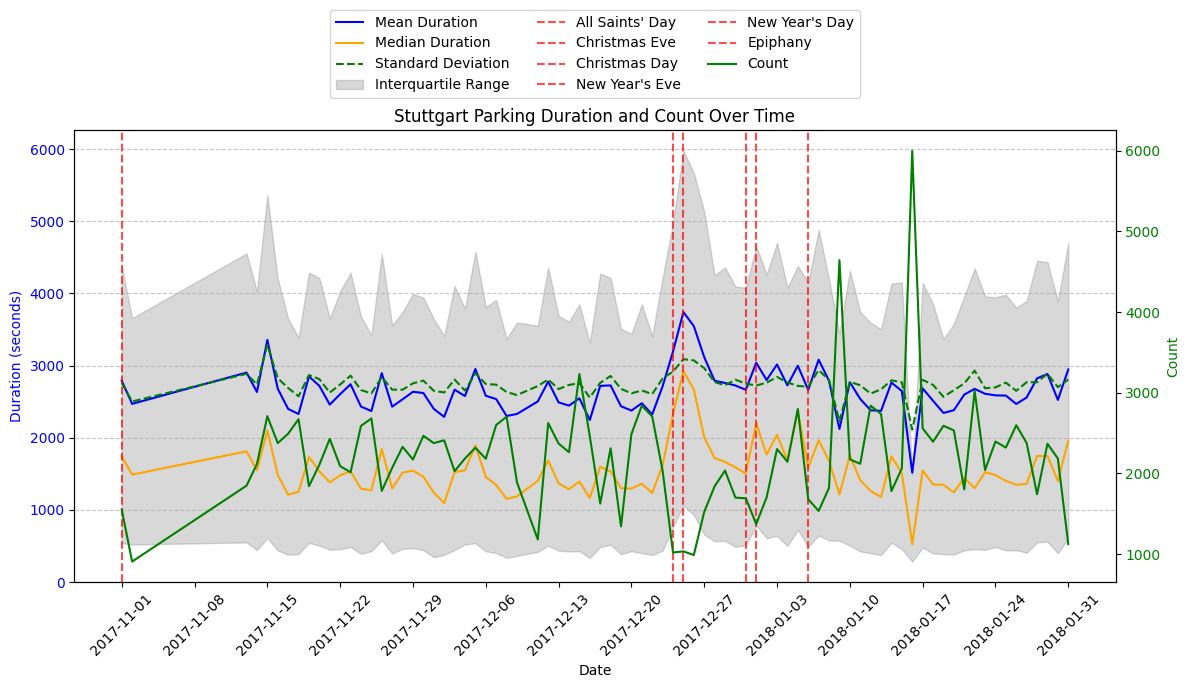

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import pytz  # Library for timezone
import numpy as np

# Define time zone for Stuttgart
timezone = pytz.timezone("Europe/Berlin")


if db is None:
    raise RuntimeError("Set MONGO_URI before running this database-dependent analysis cell.")
collection = db["PermanentParkings"]
# Define the date
start_date = pd.to_datetime("2017-11-01T00:00:00Z")
end_date = pd.to_datetime("2018-01-31T23:59:59Z")

# Fetch data for Stuttgart
results = list(collection.find(
    {
        "city": "Stuttgart",
        "init_date": {
            "$gte": start_date,
            "$lte": end_date
        }
    },
    {"init_date": 1, "final_date": 1}
))

if not results:
    print("No data found for Stuttgart.")
else:
    # Convert results into a DataFrame
    df = pd.DataFrame(results)
    df['UTC_Init'] = pd.to_datetime(df['init_date'])
    df['UTC_Final'] = pd.to_datetime(df['final_date'])

    # Calculate parking duration in seconds
    df['Duration'] = (df['UTC_Final'] - df['UTC_Init']).dt.total_seconds()

    # Convert to local time
    df['Local_Init'] = df['UTC_Init'].dt.tz_localize('UTC').dt.tz_convert(timezone)
    df['Local_Date'] = df['Local_Init'].dt.date

    # Filter data based on duration (between 1 minute and 3 hours)
    filtered_df = df[(df['Duration'] >= 60) & (df['Duration'] <= 10800)]  # 1 minute to 3 hours

    #  calculate statistics
    daily_stats = filtered_df.groupby('Local_Date')['Duration'].agg([
        ('Mean', 'mean'),  # Use Pandas
        ('Median', 'median'),  # Use Pandas
        ('Std', lambda x: np.std(x, ddof=1) if len(x) > 1 else 0),  # Custom Std Dev function
        ('25th Percentile', lambda x: np.percentile(x, 25)),
        ('75th Percentile', lambda x: np.percentile(x, 75))
    ]).reset_index()

    #  daily counts
    daily_counts = filtered_df.groupby('Local_Date').size().reset_index(name='Count')

    # Merge stats and counts
    daily_stats = pd.merge(daily_stats, daily_counts, left_on='Local_Date', right_on='Local_Date', how='left')

    # Define holidays
    holidays = {
        "All Saints' Day": "2017-11-01",
        "Christmas Eve": "2017-12-24",
        "Christmas Day": "2017-12-25",
        "New Year's Eve": "2017-12-31",
        "New Year's Day": "2018-01-01",
        "Epiphany": "2018-01-06"
    }

    # Plot statistics
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot mean, median, and standard deviation
    ax1.plot(daily_stats['Local_Date'], daily_stats['Mean'], label='Mean Duration', color='blue')
    ax1.plot(daily_stats['Local_Date'], daily_stats['Median'], label='Median Duration', color='orange')
    ax1.plot(daily_stats['Local_Date'], daily_stats['Std'], label='Standard Deviation', color='green', linestyle='--')

    # Plot percentiles
    ax1.fill_between(
        daily_stats['Local_Date'],
        daily_stats['25th Percentile'],
        daily_stats['75th Percentile'],
        color='gray', alpha=0.3, label='Interquartile Range'
    )

    ax1.set_xlabel('Date')
    ax1.set_ylabel('Duration (seconds)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Plot count on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(daily_stats['Local_Date'], daily_stats['Count'], label='Count', color='green')
    ax2.set_ylabel('Count', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Highlight holidays
    for holiday, date in holidays.items():
        ax1.axvline(pd.to_datetime(date), color='red', linestyle='--', alpha=0.7, label=holiday)

    # Set x-axis ticks to weekly intervals
    ax1.set_xticks(pd.date_range(start=daily_stats['Local_Date'].min(), end=daily_stats['Local_Date'].max(), freq='7D'))
    ax1.set_xticklabels(pd.date_range(start=daily_stats['Local_Date'].min(), end=daily_stats['Local_Date'].max(), freq='7D').strftime('%Y-%m-%d'), rotation=45)

    # Add legend
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)
    plt.title('Stuttgart Parking Duration and Count Over Time')
    plt.tight_layout()
    plt.show()


Connection successful!


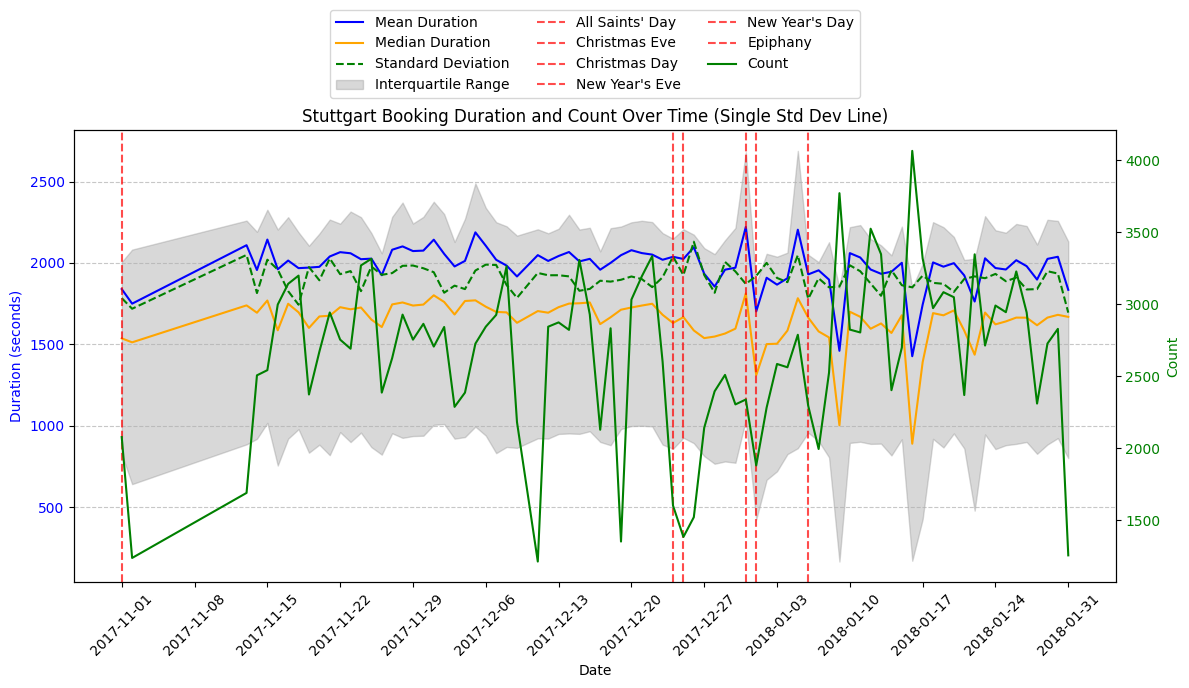

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import pytz  # Library for timezone
import numpy as np

# Define time zone for Stuttgart
timezone = pytz.timezone("Europe/Berlin")


if db is None:
    raise RuntimeError("Set MONGO_URI before running this database-dependent analysis cell.")
collection = db["PermanentBookings"]
# Define the date
start_date = pd.to_datetime("2017-11-01T00:00:00Z")
end_date = pd.to_datetime("2018-01-31T23:59:59Z")

# Fetch data for Stuttgart
results = list(collection.find(
    {
        "city": "Stuttgart",
        "init_date": {
            "$gte": start_date,
            "$lte": end_date
        }
    },
    {"init_date": 1, "final_date": 1}
))

if not results:
    print("No data found for Amsterdam.")
else:
    # Convert results into a DataFrame
    df = pd.DataFrame(results)
    df['UTC_Init'] = pd.to_datetime(df['init_date'])
    df['UTC_Final'] = pd.to_datetime(df['final_date'])

    # Calculate booking duration in seconds
    df['Duration'] = (df['UTC_Final'] - df['UTC_Init']).dt.total_seconds()

    # Convert to local time
    df['Local_Init'] = df['UTC_Init'].dt.tz_localize('UTC').dt.tz_convert(timezone)
    df['Local_Date'] = df['Local_Init'].dt.date

    # Filter data based on duration (e.g., between 2 minutes and 3 hours)
    filtered_df = df[(df['Duration'] >= 120) & (df['Duration'] <= 10800)]

    #  calculate statistics
    daily_stats = filtered_df.groupby('Local_Date')['Duration'].agg([
        ('Mean', 'mean'),  # Use Pandas
        ('Median', 'median'),  # Use Pandas
        ('Std', lambda x: np.std(x, ddof=1) if len(x) > 1 else 0),  #  Std
        ('25th Percentile', lambda x: np.percentile(x, 25)),
        ('75th Percentile', lambda x: np.percentile(x, 75))
    ]).reset_index()

    #  daily counts
    daily_counts = filtered_df.groupby('Local_Date').size().reset_index(name='Count')

    # Merge stats and counts
    daily_stats = pd.merge(daily_stats, daily_counts, left_on='Local_Date', right_on='Local_Date', how='left')

    # Define holidays
    holidays = {
        "All Saints' Day": "2017-11-01",
        "Christmas Eve": "2017-12-24",
        "Christmas Day": "2017-12-25",
        "New Year's Eve": "2017-12-31",
        "New Year's Day": "2018-01-01",
        "Epiphany": "2018-01-06"
    }

    # Plot statistics
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot mean, median, and standard deviation
    ax1.plot(daily_stats['Local_Date'], daily_stats['Mean'], label='Mean Duration', color='blue')
    ax1.plot(daily_stats['Local_Date'], daily_stats['Median'], label='Median Duration', color='orange')
    ax1.plot(daily_stats['Local_Date'], daily_stats['Std'], label='Standard Deviation', color='green', linestyle='--')

    # Plot percentiles
    ax1.fill_between(
        daily_stats['Local_Date'],
        daily_stats['25th Percentile'],
        daily_stats['75th Percentile'],
        color='gray', alpha=0.3, label='Interquartile Range'
    )

    ax1.set_xlabel('Date')
    ax1.set_ylabel('Duration (seconds)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Plot count on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(daily_stats['Local_Date'], daily_stats['Count'], label='Count', color='green')
    ax2.set_ylabel('Count', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Highlight holidays
    for holiday, date in holidays.items():
        ax1.axvline(pd.to_datetime(date), color='red', linestyle='--', alpha=0.7, label=holiday)

    # Set x-axis ticks to weekly intervals
    ax1.set_xticks(pd.date_range(start=daily_stats['Local_Date'].min(), end=daily_stats['Local_Date'].max(), freq='7D'))
    ax1.set_xticklabels(pd.date_range(start=daily_stats['Local_Date'].min(), end=daily_stats['Local_Date'].max(), freq='7D').strftime('%Y-%m-%d'), rotation=45)

    # Add legend
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)
    plt.title('Stuttgart Booking Duration and Count Over Time (Single Std Dev Line)')
    plt.tight_layout()
    plt.show()


## 📝 Notes

- This notebook is a **public portfolio adaptation** of the original course notebook.
- 🔐 Database credentials have been removed and are not stored in the repository.
- 📦 The original MongoDB dataset is not included.
- 👩‍💻 Only the analytical parts corresponding to my Lab 1 contribution are presented here.
- 📊 Existing outputs from the original analysis are retained where available to document the performed analysis.
